In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# 1) Load the given dataset

In [2]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [3]:
df = pd.read_csv("ML Project - Naïve Bayes Loan Status Classification.txt")

In [4]:
df.shape

(30000, 16)

In [5]:
df.head(5)

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,NaN,NaN,NaN,NaN,689.0,NaN,NaN,NaN,NaN,Default
1,2,12.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,NaN,1.0,1.0,1.0,NaN,2.0,Default
2,3,9.0,34,29239.0,1427.0,13559.0,14331.0,14948.0,15549.0,1518.0,15.0,1.0,1.0,1.0,5.0,Not Default
3,4,5.0,37,4699.0,48233.0,49291.0,28314.0,28959.0,29547.0,2.0,219.0,12.0,11.0,169.0,1.0,Not Default
4,5,5.0,57,8617.0,567.0,35835.0,294.0,19146.0,19131.0,2.0,36681.0,1.0,9.0,689.0,679.0,Not Default


# 2) Check the null values

In [6]:
df.isnull().sum()

ID                   0
LIMIT_BAL            0
AGE                  0
BILL_AMT1         2008
BILL_AMT2         2506
BILL_AMT3         2870
BILL_AMT4         3195
BILL_AMT5         3506
BILL_AMT6         4020
PAY_AMT1          5249
PAY_AMT2          5396
PAY_AMT3          5968
PAY_AMT4          6408
PAY_AMT5          6703
PAY_AMT6          7173
Default Status       0
dtype: int64

# 3) Print the column names

In [7]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Default Status']

# 4) Create list for all the columns which have null values

In [8]:
null_cols = [col for col in df.columns if df[col].isnull().any()]

In [9]:
null_cols

['BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

# 5) Fill all the null values with mean using for loops

In [10]:
for col in null_cols:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].mean())

In [11]:
df[col]

0        2608.76576
1           2.00000
2           5.00000
3           1.00000
4         679.00000
            ...    
29995       1.00000
29996    2608.76576
29997      31.00000
29998     184.00000
29999       1.00000
Name: PAY_AMT6, Length: 30000, dtype: float64

# 6) Get data information

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30000 non-null  int64  
 1   LIMIT_BAL       30000 non-null  float64
 2   AGE             30000 non-null  int64  
 3   BILL_AMT1       30000 non-null  float64
 4   BILL_AMT2       30000 non-null  float64
 5   BILL_AMT3       30000 non-null  float64
 6   BILL_AMT4       30000 non-null  float64
 7   BILL_AMT5       30000 non-null  float64
 8   BILL_AMT6       30000 non-null  float64
 9   PAY_AMT1        30000 non-null  float64
 10  PAY_AMT2        30000 non-null  float64
 11  PAY_AMT3        30000 non-null  float64
 12  PAY_AMT4        30000 non-null  float64
 13  PAY_AMT5        30000 non-null  float64
 14  PAY_AMT6        30000 non-null  float64
 15  Default Status  30000 non-null  object 
dtypes: float64(13), int64(2), object(1)
memory usage: 3.7+ MB


# 7) Describe dataset

In [14]:
df.describe()

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,10666.660700,14.648867,32.427900,33989.494570,33938.750418,32617.867011,30709.50416,29015.123424,28526.276559,2613.957537,2.922762e+03,2584.508988,2250.186122,2300.375885,2608.765760
std,9698.091793,189.496507,12.718991,59472.881131,58305.224138,55777.906879,51825.29715,48612.594594,48042.412239,11398.052166,1.675277e+04,10956.873040,9805.177073,9756.444917,11652.208534
min,1.000000,1.000000,3.000000,-154973.000000,-69777.000000,-157264.000000,-81334.00000,-81334.000000,-94625.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000
25%,1850.500000,4.000000,26.000000,1788.000000,1847.750000,1862.000000,1782.00000,1718.000000,1724.000000,21.000000,1.900000e+01,15.000000,13.000000,13.000000,15.000000
50%,7483.500000,9.000000,33.000000,11569.000000,12637.000000,13255.000000,13350.00000,12847.000000,13398.500000,512.000000,5.150000e+02,431.000000,367.000000,387.000000,478.000000
75%,18746.250000,21.000000,41.000000,33989.494570,33938.750418,32617.867011,30709.50416,29015.123424,28526.276559,2613.957537,2.922762e+03,2584.508988,2250.186122,2300.375885,2608.765760
max,29999.000000,32768.000000,79.000000,964511.000000,983931.000000,693131.000000,891586.00000,927171.000000,961664.000000,873552.000000,1.684259e+06,417588.000000,528897.000000,426529.000000,528666.000000


# 8) Display box plot for LIMIT_BAL

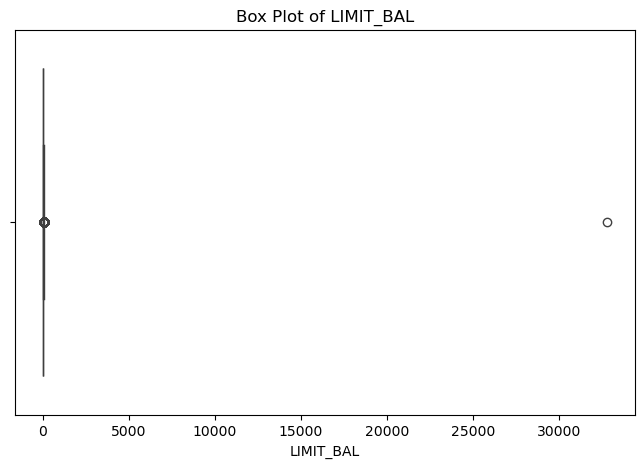

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["LIMIT_BAL"])
plt.title("Box Plot of LIMIT_BAL")
plt.show()

# 9) Display box plot for age

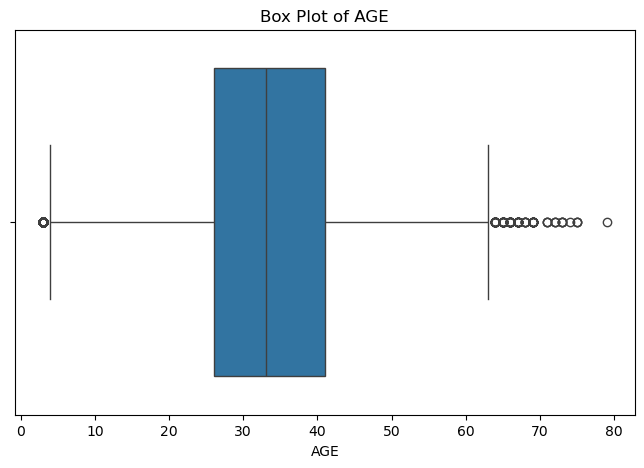

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['AGE'])
plt.title('Box Plot of AGE')
plt.show()

# 10) Drop all the remaining null values 

In [17]:
df.dropna(inplace=True)

# 11) Perform encoding on default status

In [18]:
le = LabelEncoder()

In [25]:
df["Default Status"] = le.fit_transform(df["Default Status"])

# Part-2: Working with Models
# 1) Create a features (X) and target (y) dataset

In [26]:
x = df.drop(["Default Status"], axis=1) 
y = df["Default Status"]

# 2) Split data into training and testing (standard 80/20 split)

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3) Fit the Gaussian naive bayes classifier

In [28]:
-gnb = GaussianNB()

In [30]:
gnb.fit(x_train, y_train)

GaussianNB()

yp_train = gnb.predict(x_train)
yp_test = gnb.predict(x_test)

# 4) Print the training score

In [32]:
gnb.score(x_train, y_train)

0.7503333333333333

# 5) Print the testing score

In [33]:
gnb.score(x_test, y_test)

0.7511666666666666

# 6) Find the accuracy score

In [34]:
accuracy_score(y_test,yp_test)

0.7511666666666666

# 7) Find the precision score

In [35]:
precision_score(y_test,yp_test)

0.7787085514834206

# 8) Find the recall score

In [36]:
recall_score(y_test,yp_test)

0.9519948794538085

# 9) Find the Confusion matrix

In [37]:
confusion_matrix(y_test,yp_test)

array([[  45, 1268],
       [ 225, 4462]])

# 10) Find the Classification report

In [38]:
classification_report(y_test, yp_test)

'              precision    recall  f1-score   support\n\n           0       0.17      0.03      0.06      1313\n           1       0.78      0.95      0.86      4687\n\n    accuracy                           0.75      6000\n   macro avg       0.47      0.49      0.46      6000\nweighted avg       0.64      0.75      0.68      6000\n'